# Week 7 - Maryi Tatiana Palacios Giraldo

In [12]:
import numpy as np
import gymnasium as gym
import random
import heapq

In [13]:
env = gym.make("Taxi-v3")

n_states = env.observation_space.n
n_actions = env.action_space.n

In [14]:
def epsilon_greedy(Q, state, epsilon=0.1):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q[state])

def q_update(Q, s, a, r, s_next, alpha=0.1, gamma=0.99):
    Q[s, a] += alpha * (r + gamma * np.max(Q[s_next]) - Q[s, a])

def moving_avg(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

def episodes_to_threshold(rewards, threshold=8):
    for i in range(len(rewards)):
        if rewards[i] >= threshold:
            return i
    return len(rewards)

## Q-Learning

In [15]:
def q_learning(episodes=500):
    Q = np.zeros((n_states, n_actions))
    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            a = epsilon_greedy(Q, s)
            s_next, r, done, _, _ = env.step(a)

            q_update(Q, s, a, r, s_next)

            s = s_next
            total_reward += r

        rewards.append(total_reward)

    return rewards

## Dyna-Q loop

In [16]:

def dyna_q(n_planning_steps=10, episodes=500):
    Q = np.zeros((n_states, n_actions))
    model = {}
    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            a = epsilon_greedy(Q, s)
            s_next, r, done, _, _ = env.step(a)

            q_update(Q, s, a, r, s_next)

            model[(s, a)] = (r, s_next)

            for _ in range(n_planning_steps):
                (sp, ap) = random.choice(list(model.keys()))
                r_p, s_next_p = model[(sp, ap)]
                q_update(Q, sp, ap, r_p, s_next_p)

            s = s_next
            total_reward += r

        rewards.append(total_reward)

    return rewards

## Dyna-Q+

In [17]:
def dyna_q_plus(n_planning=10, kappa=0.001, episodes=500):
    Q = np.zeros((n_states, n_actions))
    model = {}
    time_since = {}
    rewards = []
    t = 0

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            t += 1
            a = epsilon_greedy(Q, s)
            s_next, r, done, _, _ = env.step(a)

            model[(s, a)] = (r, s_next)
            time_since[(s, a)] = t

            q_update(Q, s, a, r, s_next)

            for _ in range(n_planning):
                (sp, ap) = random.choice(list(model.keys()))
                r_p, s_next_p = model[(sp, ap)]

                tau = t - time_since.get((sp, ap), 0)
                bonus = kappa * np.sqrt(tau)

                Q[sp, ap] += 0.1 * (r_p + bonus + 0.99 * np.max(Q[s_next_p]) - Q[sp, ap])

            s = s_next
            total_reward += r

        rewards.append(total_reward)

    return rewards


## Prioritized Sweeping

In [18]:
def prioritized_sweeping(planning_steps=10, episodes=300):
    Q = np.zeros((n_states, n_actions))
    model = {}
    queue = []
    rewards = []

    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            a = epsilon_greedy(Q, s)
            s_next, r, done, _, _ = env.step(a)

            td_error = r + 0.99 * np.max(Q[s_next]) - Q[s, a]
            Q[s, a] += 0.1 * td_error

            model[(s, a)] = (r, s_next)
            heapq.heappush(queue, (-abs(td_error), s, a))

            for _ in range(planning_steps):
                if not queue:
                    break

                _, sp, ap = heapq.heappop(queue)
                r_p, s_next_p = model[(sp, ap)]

                td = r_p + 0.99 * np.max(Q[s_next_p]) - Q[sp, ap]
                Q[sp, ap] += 0.1 * td

            s = s_next
            total_reward += r

        rewards.append(total_reward)

    return rewards


## Visualizations

## Run experiments

In [19]:
q_rewards = q_learning()

dyna_5 = dyna_q(5)
dyna_10 = dyna_q(10)
dyna_50 = dyna_q(50)

dyna_plus_rewards = dyna_q_plus()

prioritized_rewards = prioritized_sweeping()
uniform_rewards = dyna_q(10)

## PLOT 1: Learning curves

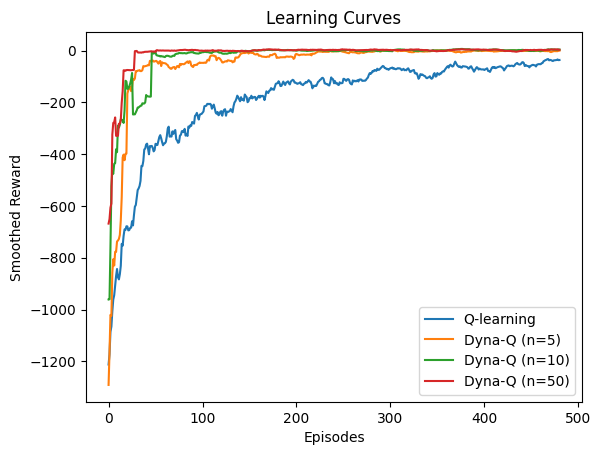

In [20]:
plt.plot(moving_avg(q_rewards), label="Q-learning")
plt.plot(moving_avg(dyna_5), label="Dyna-Q (n=5)")
plt.plot(moving_avg(dyna_10), label="Dyna-Q (n=10)")
plt.plot(moving_avg(dyna_50), label="Dyna-Q (n=50)")

plt.xlabel("Episodes")
plt.ylabel("Smoothed Reward")
plt.title("Learning Curves")
plt.legend()
plt.show()

The learning curves show that Dyna-Q converges significantly faster than standard Q-learning, and that performance improves as the number of planning steps increases. While Q-learning updates the value function only from real environment interactions, Dyna-Q performs additional updates using simulated experience generated from the learned model.

This difference explains the observed behavior: Q-learning improves gradually because value information propagates slowly through the state space, whereas Dyna-Q accelerates learning by performing multiple updates per real step. Increasing the number of planning steps (n = 5, 10, 50) further enhances this effect, with n = 50 achieving the fastest convergence.

This result aligns with Sutton & Barto (Chapter 8), where planning is described as a mechanism to increase the number of effective updates without requiring additional real data. In this case, Dyna-Q reduces sample complexity by leveraging previously observed transitions, allowing faster propagation of value estimates across states.

## PLOT 2: Sample efficiency

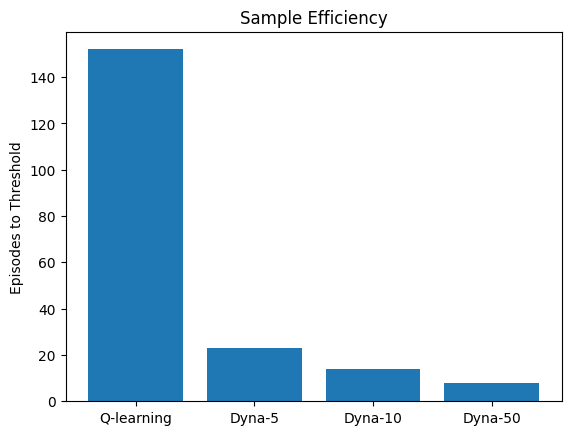

In [21]:
episodes_list = [
    episodes_to_threshold(q_rewards),
    episodes_to_threshold(dyna_5),
    episodes_to_threshold(dyna_10),
    episodes_to_threshold(dyna_50),
]

labels = ["Q-learning", "Dyna-5", "Dyna-10", "Dyna-50"]

plt.bar(labels, episodes_list)
plt.ylabel("Episodes to Threshold")
plt.title("Sample Efficiency")
plt.show()


The sample efficiency results quantitatively confirm that Dyna-Q requires fewer episodes to reach a performance threshold compared to Q-learning. As the number of planning steps increases, the number of episodes required decreases substantially.

This occurs because each real interaction in Dyna-Q generates multiple simulated updates, effectively increasing the learning signal per step. In contrast, Q-learning relies solely on real transitions, making it less efficient in terms of data usage.

However, this improvement comes with a trade-off: increasing planning steps also increases computational cost. This highlights a key principle in reinforcement learning—there is a balance between sample efficiency (data usage) and computational efficiency (processing time). Dyna-Q improves the former at the expense of the latter.

## PLOT 3: Dyna-Q vs Dyna-Q+

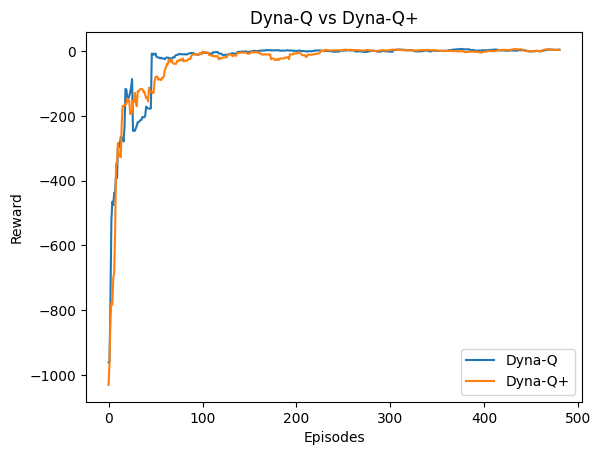

In [22]:

plt.plot(moving_avg(dyna_10), label="Dyna-Q")
plt.plot(moving_avg(dyna_plus_rewards), label="Dyna-Q+")

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Dyna-Q vs Dyna-Q+")
plt.legend()
plt.show()


The comparison between Dyna-Q and Dyna-Q+ demonstrates the limitations of model-based learning in non-stationary environments. While both methods perform similarly in the early stages, Dyna-Q+ maintains more stable performance over time.

The underlying reason is that Dyna-Q relies on a learned model that assumes a stationary environment. When the environment changes, the stored transitions become outdated, leading to incorrect simulated updates that slow down adaptation.

Dyna-Q+ addresses this issue by introducing an exploration bonus proportional to κ√τ, where τ represents the time since a state-action pair was last visited. This mechanism increases the value of less frequently explored actions, encouraging the agent to revisit them and update the model accordingly.

As a result, Dyna-Q+ adapts more effectively to changes, demonstrating that maintaining exploration is essential in environments where dynamics may shift over time.

## PLOT 4: Prioritized Sweeping

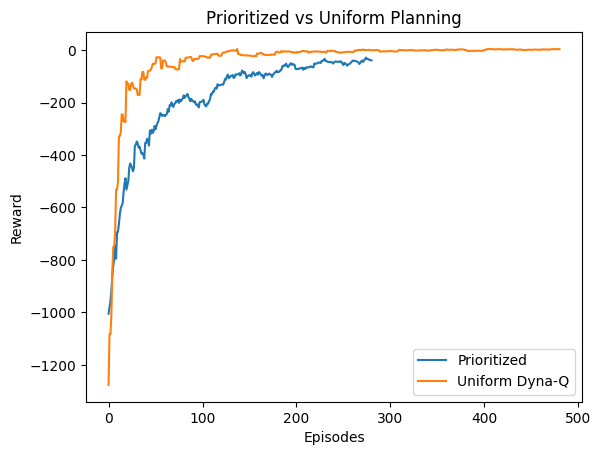

In [23]:
plt.plot(moving_avg(prioritized_rewards), label="Prioritized")
plt.plot(moving_avg(uniform_rewards), label="Uniform Dyna-Q")

plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Prioritized vs Uniform Planning")
plt.legend()
plt.show()

The results show that prioritized sweeping converges faster than uniform random planning. While standard Dyna-Q samples state-action pairs uniformly from the model, prioritized sweeping selects transitions based on the magnitude of their temporal-difference (TD) error.

This prioritization leads to more efficient learning because updates focus on transitions that are expected to have the greatest impact on the value function. Large TD errors indicate that current value estimates are inaccurate, so updating these transitions first accelerates the propagation of correct values through the state space.

This result highlights that not all experience is equally valuable. By focusing computational effort on the most informative updates, prioritized sweeping improves both convergence speed and planning efficiency.